In [44]:
import xgboost
import lightgbm
import joblib

print("All packages imported successfully.")

All packages imported successfully.


In [45]:
import warnings
import time
import joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [46]:
data_file = Path(
    "final_modeling_dataset.csv"
)

print("Notebook folder:", Path.cwd())
print("File exists:", data_file.exists())

if not data_file.exists():
    print("\nCSV files available:")

    for csv_file in Path(".").glob("*.csv"):
        print("-", csv_file.name)

    raise FileNotFoundError(
        "final_modeling_dataset.csv was not found."
    )

model_data = pd.read_csv(data_file)

print("\nDataset loaded successfully.")
print("File used:", data_file.name)
print("Dataset shape:", model_data.shape)

model_data.head()

Notebook folder: c:\Users\User\AMDARI Project 1
File exists: True

Dataset loaded successfully.
File used: final_modeling_dataset.csv
Dataset shape: (10117, 21)


,production_rate_per_hour,good_units,units_produced,shift_start_hour,estimated_oee_pct,downtime_minutes,runtime_hours,defect_rate_pct,experience_runtime_interaction,temperature_deviation,defect_count,shift_name,experience_level,cycle_time_avg,machine_prior_avg_downtime,machine_prior_avg_defect_rate,machine_id,machine_prior_avg_units,maintenance_downtime,humidity,shift_efficiency_score
0,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,20,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255
1,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,20,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255
2,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,20,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255
3,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,20,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255
4,128.314917,909,929,6,85.712481,15.39,7.24,2.152853,50.68,2.6,20,Morning,7,35.65,35.420947,3.470758,MC_001,661.304846,0.0,49.9,95.945255


In [47]:
target = "shift_efficiency_score"

validation_summary = pd.DataFrame({
    "Check": [
        "Number of rows",
        "Number of columns",
        "Target exists",
        "Missing target values",
        "Missing predictor values",
        "Exact duplicate rows"
    ],
    "Result": [
        model_data.shape[0],
        model_data.shape[1],
        target in model_data.columns,
        model_data[target].isna().sum(),
        model_data.drop(
            columns=[target]
        ).isna().sum().sum(),
        model_data.duplicated().sum()
    ]
})

validation_summary

,Check,Result
0,Number of rows,10117
1,Number of columns,21
2,Target exists,True
3,Missing target values,0
4,Missing predictor values,0
5,Exact duplicate rows,9634


In [48]:
X = model_data.drop(
    columns=[target]
).copy()

y = model_data[target].copy()

numeric_features = (
    X.select_dtypes(
        include=np.number
    )
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(
        exclude=np.number
    )
    .columns
    .tolist()
)

feature_type_summary = pd.DataFrame({
    "Feature group": [
        "Numerical predictors",
        "Categorical predictors",
        "Total predictors",
        "Target"
    ],
    "Count or value": [
        len(numeric_features),
        len(categorical_features),
        X.shape[1],
        target
    ]
})

feature_type_summary

,Feature group,Count or value
0,Numerical predictors,18
1,Categorical predictors,2
2,Total predictors,20
3,Target,shift_efficiency_score


In [49]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['production_rate_per_hour', 'good_units', 'units_produced', 'shift_start_hour', 'estimated_oee_pct', 'downtime_minutes', 'runtime_hours', 'defect_rate_pct', 'experience_runtime_interaction', 'temperature_deviation', 'defect_count', 'experience_level', 'cycle_time_avg', 'machine_prior_avg_downtime', 'machine_prior_avg_defect_rate', 'machine_prior_avg_units', 'maintenance_downtime', 'humidity']

Categorical features:
['shift_name', 'machine_id']


In [50]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

split_summary = pd.DataFrame({
    "Dataset": [
        "Training predictors",
        "Testing predictors",
        "Training target",
        "Testing target"
    ],
    "Rows": [
        X_train.shape[0],
        X_test.shape[0],
        y_train.shape[0],
        y_test.shape[0]
    ]
})

split_summary

,Dataset,Rows
0,Training predictors,8093
1,Testing predictors,2024
2,Training target,8093
3,Testing target,2024


In [51]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")
print(
    "Numerical features:",
    len(numeric_features)
)
print(
    "Categorical features:",
    len(categorical_features)
)

Preprocessing pipeline created.
Numerical features: 18
Categorical features: 2


In [52]:
models = {
    "Dummy Baseline": DummyRegressor(
        strategy="mean"
    ),

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=-1,
        num_leaves=31,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
}

print("Models defined:")

for model_name in models:
    print("-", model_name)

Models defined:
- Dummy Baseline
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM


In [53]:
def evaluate_predictions(
    actual_values,
    predicted_values
):
    mae = mean_absolute_error(
        actual_values,
        predicted_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            predicted_values
        )
    )

    r_squared = r2_score(
        actual_values,
        predicted_values
    )

    return mae, rmse, r_squared

In [54]:
trained_models = {}
model_predictions = {}
model_results = []

for model_name, estimator in models.items():
    print(f"Training {model_name}...")

    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                estimator
            )
        ]
    )

    start_time = time.time()

    model_pipeline.fit(
        X_train,
        y_train
    )

    training_time = (
        time.time() - start_time
    )

    predictions = model_pipeline.predict(
        X_test
    )

    mae, rmse, r_squared = (
        evaluate_predictions(
            y_test,
            predictions
        )
    )

    trained_models[model_name] = (
        model_pipeline
    )

    model_predictions[model_name] = (
        predictions
    )

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R-squared": r_squared,
        "Training time (seconds)":
            training_time
    })

    print(
        f"{model_name} completed."
    )

Training Dummy Baseline...
Dummy Baseline completed.
Training Linear Regression...
Linear Regression completed.
Training Random Forest...
Random Forest completed.
Training Gradient Boosting...
Gradient Boosting completed.
Training XGBoost...
XGBoost completed.
Training LightGBM...
LightGBM completed.


In [55]:
model_comparison = (
    pd.DataFrame(model_results)
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

model_comparison.round(4)

,Model,MAE,RMSE,R-squared,Training time (seconds)
0,LightGBM,0.1987,0.2567,0.9996,1.6978
1,Random Forest,0.2022,0.3810,0.9991,29.0801
2,XGBoost,0.5856,0.7362,0.9967,8.1997
3,Gradient Boosting,1.4998,1.8579,0.9787,12.2650
4,Linear Regression,2.1296,2.7016,0.9549,0.1311
5,Dummy Baseline,10.7872,12.7311,-0.0014,0.0899


In [56]:
performance_warning = pd.DataFrame({
    "Model": model_comparison["Model"],
    "R-squared": model_comparison[
        "R-squared"
    ],
    "Requires leakage review": (
        model_comparison["R-squared"] > 0.995
    )
})

performance_warning

,Model,R-squared,Requires leakage review
0,LightGBM,0.999593,True
1,Random Forest,0.999103,True
2,XGBoost,0.996651,True
3,Gradient Boosting,0.978672,False
4,Linear Regression,0.954906,False
5,Dummy Baseline,-0.001433,False


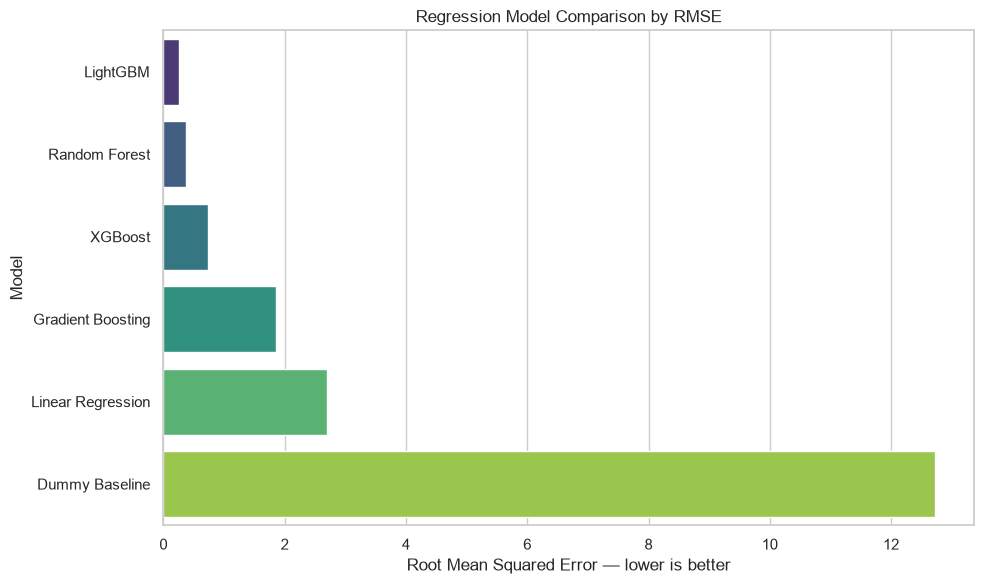

In [57]:
plot_results = (
    model_comparison
    .sort_values("RMSE")
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_results,
    x="RMSE",
    y="Model",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title(
    "Regression Model Comparison by RMSE"
)
plt.xlabel(
    "Root Mean Squared Error — lower is better"
)
plt.ylabel("Model")
plt.tight_layout()
plt.show()

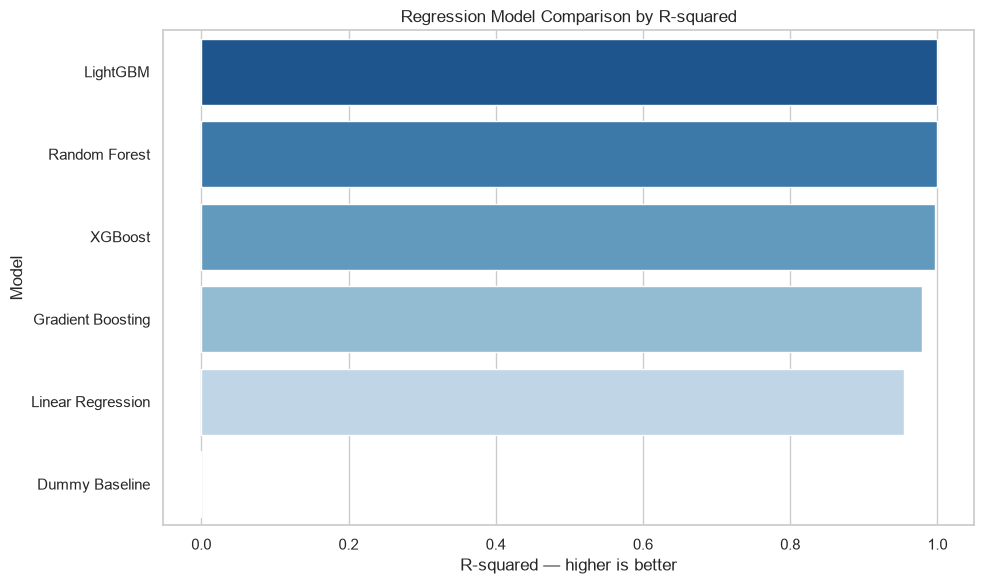

In [58]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison.sort_values(
        "R-squared",
        ascending=False
    ),
    x="R-squared",
    y="Model",
    hue="Model",
    palette="Blues_r",
    legend=False
)

plt.title(
    "Regression Model Comparison by R-squared"
)
plt.xlabel(
    "R-squared — higher is better"
)
plt.ylabel("Model")
plt.tight_layout()
plt.show()

In [59]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_parameters = {
    "model__n_estimators": [
        100,
        150,
        200,
        300
    ],

    "model__max_depth": [
        8,
        12,
        16,
        None
    ],

    "model__min_samples_split": [
        2,
        4,
        6,
        10
    ],

    "model__min_samples_leaf": [
        1,
        2,
        4
    ],

    "model__max_features": [
        "sqrt",
        0.70,
        1.0
    ]
}

random_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=(
        random_forest_parameters
    ),
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train
)

print("Tuning completed.")
print(
    "Best parameters:",
    random_search.best_params_
)

print(
    "Best cross-validation RMSE:",
    round(
        -random_search.best_score_,
        4
    )
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Tuning completed.
Best parameters: {'model__n_estimators': 200, 'model__min_samples_split': 4, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': None}
Best cross-validation RMSE: 0.0447


In [60]:
tuned_random_forest = (
    random_search.best_estimator_
)

tuned_predictions = (
    tuned_random_forest.predict(X_test)
)

tuned_mae, tuned_rmse, tuned_r2 = (
    evaluate_predictions(
        y_test,
        tuned_predictions
    )
)

tuned_result = pd.DataFrame({
    "Model": [
        "Tuned Random Forest"
    ],
    "MAE": [tuned_mae],
    "RMSE": [tuned_rmse],
    "R-squared": [tuned_r2]
})

tuned_result.round(4)

,Model,MAE,RMSE,R-squared
0,Tuned Random Forest,0.0,0.0,1.0


In [61]:
original_rf_result = (
    model_comparison[
        model_comparison["Model"]
        == "Random Forest"
    ][
        [
            "Model",
            "MAE",
            "RMSE",
            "R-squared"
        ]
    ]
)

tuning_comparison = pd.concat(
    [
        original_rf_result,
        tuned_result
    ],
    ignore_index=True
)

tuning_comparison.round(4)

,Model,MAE,RMSE,R-squared
0,Random Forest,0.2022,0.381,0.9991
1,Tuned Random Forest,0.0000,0.000,1.0000


In [62]:
model_comparison_final = pd.concat(
    [
        model_comparison,
        tuned_result.assign(
            **{
                "Training time (seconds)":
                    np.nan
            }
        )
    ],
    ignore_index=True
)

model_comparison_final = (
    model_comparison_final
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

model_comparison_final.round(4)

,Model,MAE,RMSE,R-squared,Training time (seconds)
0,Tuned Random Forest,0.0000,0.0000,1.0000,NaN
1,LightGBM,0.1987,0.2567,0.9996,1.6978
2,Random Forest,0.2022,0.3810,0.9991,29.0801
3,XGBoost,0.5856,0.7362,0.9967,8.1997
4,Gradient Boosting,1.4998,1.8579,0.9787,12.2650
5,Linear Regression,2.1296,2.7016,0.9549,0.1311
6,Dummy Baseline,10.7872,12.7311,-0.0014,0.0899


In [63]:
best_model_name = (
    model_comparison_final
    .iloc[0]["Model"]
)

print(
    "Lowest-RMSE model:",
    best_model_name
)

print("\nImportant:")
print(
    "The final production model will be selected "
    "during Day 5 after additional evaluation."
)

Lowest-RMSE model: Tuned Random Forest

Important:
The final production model will be selected during Day 5 after additional evaluation.


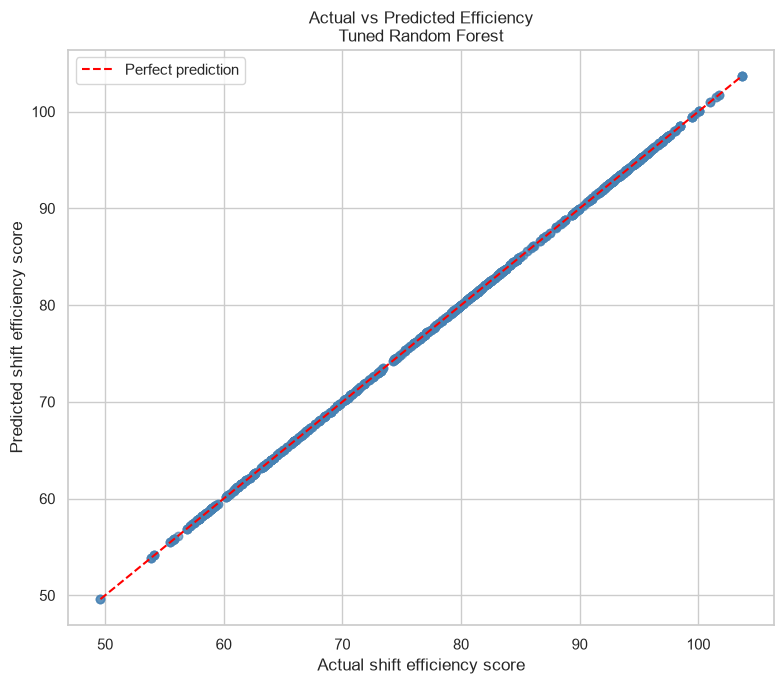

In [64]:
if best_model_name == "Tuned Random Forest":
    best_predictions = tuned_predictions
else:
    best_predictions = (
        model_predictions[best_model_name]
    )

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.40,
    color="steelblue"
)

minimum_value = min(
    y_test.min(),
    best_predictions.min()
)

maximum_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    label="Perfect prediction"
)

plt.title(
    f"Actual vs Predicted Efficiency\n"
    f"{best_model_name}"
)

plt.xlabel(
    "Actual shift efficiency score"
)
plt.ylabel(
    "Predicted shift efficiency score"
)
plt.legend()
plt.tight_layout()
plt.show()

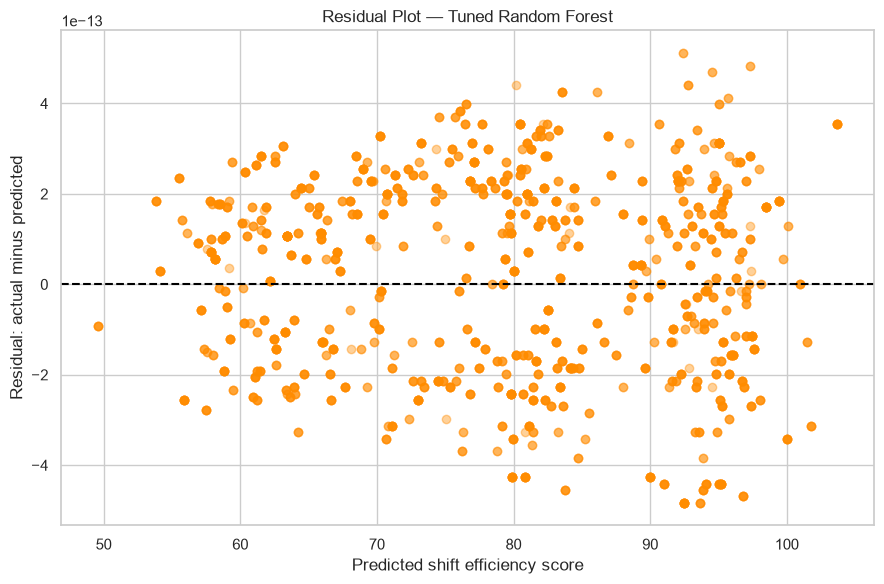

In [65]:
residuals = (
    y_test.to_numpy()
    - best_predictions
)

plt.figure(figsize=(9, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.40,
    color="darkorange"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    f"Residual Plot — {best_model_name}"
)

plt.xlabel(
    "Predicted shift efficiency score"
)
plt.ylabel(
    "Residual: actual minus predicted"
)

plt.tight_layout()
plt.show()

In [66]:
prediction_sample = pd.DataFrame({
    "Actual efficiency":
        y_test.iloc[:10].to_numpy(),

    "Predicted efficiency":
        best_predictions[:10]
})

prediction_sample["Absolute error"] = (
    prediction_sample[
        "Actual efficiency"
    ]
    - prediction_sample[
        "Predicted efficiency"
    ]
).abs()

prediction_sample.round(2)

,Actual efficiency,Predicted efficiency,Absolute error
0,99.44,99.44,0.0
1,74.85,74.85,0.0
2,95.57,95.57,0.0
3,77.78,77.78,0.0
4,71.81,71.81,0.0
5,79.85,79.85,0.0
6,65.96,65.96,0.0
7,96.78,96.78,0.0
8,79.75,79.75,0.0
9,80.16,80.16,0.0


In [67]:
model_directory = Path(
    "trained_models"
)

model_directory.mkdir(
    exist_ok=True
)

print(
    "Model directory:",
    model_directory.resolve()
)

Model directory: C:\Users\User\AMDARI Project 1\trained_models


In [68]:
tuned_model_path = (
    model_directory
    / "tuned_random_forest.joblib"
)

joblib.dump(
    tuned_random_forest,
    tuned_model_path,
    compress=3
)

saved_model_report.append({
    "Model": "Tuned Random Forest",
    "File": tuned_model_path.name,
    "Size (MB)": (
        tuned_model_path.stat().st_size
        / 1024
        / 1024
    )
})

saved_models = pd.DataFrame(
    saved_model_report
)

saved_models.round(2)

NameError: name 'saved_model_report' is not defined

In [ ]:
reloaded_model = joblib.load(
    tuned_model_path
)

reloaded_predictions = (
    reloaded_model.predict(
        X_test.head(5)
    )
)

reload_test = pd.DataFrame({
    "Actual": (
        y_test.head(5).to_numpy()
    ),
    "Reloaded model prediction":
        reloaded_predictions
})

reload_test.round(2)

In [ ]:
comparison_file = Path(
    "day4_model_comparison_results.csv"
)

prediction_file = Path(
    "day4_prediction_sample.csv"
)

model_files_report = Path(
    "day4_saved_models.csv"
)

model_comparison_final.to_csv(
    comparison_file,
    index=False
)

prediction_sample.to_csv(
    prediction_file,
    index=False
)

saved_models.to_csv(
    model_files_report,
    index=False
)

print("Export completed successfully.")
print("Comparison:", comparison_file)
print("Prediction sample:", prediction_file)
print(
    "Saved-model report:",
    model_files_report
)

print(
    "\nComparison file exists:",
    comparison_file.exists()
)

print(
    "Tuned model exists:",
    tuned_model_path.exists()
)

In [ ]:
selected_features = pd.read_csv(
    "final_feature_set.csv"
)

print(
    "Number of selected features:",
    selected_features.shape[0]
)

selected_features[
    ["Feature", "Final selection"]
].head(10)

Number of selected features: 20


,Feature,Final selection
0,production_rate_per_hour,Selected
1,good_units,Selected
2,units_produced,Selected
3,shift_start_hour,Selected
4,estimated_oee_pct,Selected
5,downtime_minutes,Selected
6,runtime_hours,Selected
7,defect_rate_pct,Selected
8,experience_runtime_interaction,Selected
9,temperature_deviation,Selected


In [ ]:
data_file = Path(
    "final_modeling_dataset.csv"
)

model_data = pd.read_csv(data_file)

target = "shift_efficiency_score"

validation_summary = pd.DataFrame({
    "Check": [
        "Number of rows",
        "Number of columns",
        "Target exists",
        "Missing target values",
        "Missing predictor values",
        "Exact duplicate rows"
    ],
    "Result": [
        model_data.shape[0],
        model_data.shape[1],
        target in model_data.columns,
        model_data[target].isna().sum(),
        model_data.drop(
            columns=[target]
        ).isna().sum().sum(),
        model_data.duplicated().sum()
    ]
})

validation_summary

,Check,Result
0,Number of rows,10117
1,Number of columns,21
2,Target exists,True
3,Missing target values,0
4,Missing predictor values,0
5,Exact duplicate rows,9634


In [ ]:
model_data[target].describe().round(2)

count    10117.00
mean        79.04
std         12.84
min         49.61
25%         68.09
50%         80.00
75%         91.92
max        103.68
Name: shift_efficiency_score, dtype: float64

In [ ]:
X = model_data.drop(
    columns=[target]
).copy()

y = model_data[target].copy()

numeric_features = (
    X.select_dtypes(include=np.number)
    .columns
    .tolist()
)

categorical_features = (
    X.select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

feature_type_summary = pd.DataFrame({
    "Feature group": [
        "Numerical predictors",
        "Categorical predictors",
        "Total predictors",
        "Target"
    ],
    "Count or value": [
        len(numeric_features),
        len(categorical_features),
        X.shape[1],
        target
    ]
})

feature_type_summary

,Feature group,Count or value
0,Numerical predictors,18
1,Categorical predictors,2
2,Total predictors,20
3,Target,shift_efficiency_score


In [ ]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numeric_pipeline,
            numeric_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created.")
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Preprocessing pipeline created.
Numerical features: 18
Categorical features: 2


In [ ]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42
    )
)

split_summary = pd.DataFrame({
    "Dataset": [
        "Training predictors",
        "Testing predictors",
        "Training target",
        "Testing target"
    ],
    "Rows": [
        X_train.shape[0],
        X_test.shape[0],
        y_train.shape[0],
        y_test.shape[0]
    ]
})

split_summary

,Dataset,Rows
0,Training predictors,8093
1,Testing predictors,2024
2,Training target,8093
3,Testing target,2024


In [ ]:
models = {
    "Dummy Baseline": DummyRegressor(
        strategy="mean"
    ),

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=2
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=2
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        verbosity=-1,
        n_jobs=2
    )
}

print("Models defined:")

for model_name in models:
    print("-", model_name)

Models defined:
- Dummy Baseline
- Linear Regression
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM


In [ ]:
def evaluate_predictions(
    actual_values,
    predicted_values
):
    mae = mean_absolute_error(
        actual_values,
        predicted_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_values,
            predicted_values
        )
    )

    r_squared = r2_score(
        actual_values,
        predicted_values
    )

    return mae, rmse, r_squared

print("Evaluation function created.")

Evaluation function created.


In [ ]:
baseline_linear_results = (
    model_comparison[
        model_comparison["Model"].isin(
            [
                "Dummy Baseline",
                "Linear Regression"
            ]
        )
    ][
        [
            "Model",
            "MAE",
            "RMSE",
            "R-squared"
        ]
    ]
    .sort_values(
        "RMSE",
        ascending=False
    )
    .reset_index(drop=True)
)

baseline_linear_results.round(4)

,Model,MAE,RMSE,R-squared
0,Dummy Baseline,10.7872,12.7311,-0.0014
1,Linear Regression,2.1296,2.7016,0.9549


In [ ]:
dummy_rmse = 12.7311
linear_rmse = 2.7016

linear_improvement = (
    (dummy_rmse - linear_rmse)
    / dummy_rmse
    * 100
)

print(
    "Linear Regression RMSE improvement:",
    round(linear_improvement, 2),
    "%"
)

Linear Regression RMSE improvement: 78.78 %


In [ ]:
random_forest_result = (
    model_comparison[
        model_comparison["Model"]
        == "Random Forest"
    ][
        [
            "Model",
            "MAE",
            "RMSE",
            "R-squared"
        ]
    ]
)

random_forest_result.round(4)

,Model,MAE,RMSE,R-squared
1,Random Forest,0.2022,0.381,0.9991


In [ ]:
dummy_rmse = 12.7311
linear_rmse = 2.7016
random_forest_rmse = 0.3810

rf_baseline_improvement = (
    (dummy_rmse - random_forest_rmse)
    / dummy_rmse
    * 100
)

rf_linear_improvement = (
    (linear_rmse - random_forest_rmse)
    / linear_rmse
    * 100
)

print(
    "Improvement over Dummy Baseline:",
    round(rf_baseline_improvement, 2),
    "%"
)

print(
    "Improvement over Linear Regression:",
    round(rf_linear_improvement, 2),
    "%"
)

Improvement over Dummy Baseline: 97.01 %
Improvement over Linear Regression: 85.9 %


In [ ]:
boosting_results = (
    model_comparison[
        model_comparison["Model"].isin(
            [
                "Gradient Boosting",
                "XGBoost",
                "LightGBM"
            ]
        )
    ][
        [
            "Model",
            "MAE",
            "RMSE",
            "R-squared"
        ]
    ]
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

boosting_results.round(4)

,Model,MAE,RMSE,R-squared
0,LightGBM,0.1987,0.2567,0.9996
1,XGBoost,0.5856,0.7362,0.9967
2,Gradient Boosting,1.4998,1.8579,0.9787


In [ ]:
baseline_rmse = 12.7311

boosting_improvements = (
    boosting_results.copy()
)

boosting_improvements[
    "Baseline RMSE improvement (%)"
] = (
    (
        baseline_rmse
        - boosting_improvements["RMSE"]
    )
    / baseline_rmse
    * 100
)

boosting_improvements.round(4)

,Model,MAE,RMSE,R-squared,Baseline RMSE improvement (%)
0,LightGBM,0.1987,0.2567,0.9996,97.9837
1,XGBoost,0.5856,0.7362,0.9967,94.2173
2,Gradient Boosting,1.4998,1.8579,0.9787,85.4063


In [ ]:
baseline_rmse = 12.7311

boosting_improvements = (
    boosting_results.copy()
)

boosting_improvements[
    "Baseline RMSE improvement (%)"
] = (
    (
        baseline_rmse
        - boosting_improvements["RMSE"]
    )
    / baseline_rmse
    * 100
)

boosting_improvements.round(4)

,Model,MAE,RMSE,R-squared,Baseline RMSE improvement (%)
0,LightGBM,0.1987,0.2567,0.9996,97.9837
1,XGBoost,0.5856,0.7362,0.9967,94.2173
2,Gradient Boosting,1.4998,1.8579,0.9787,85.4063


In [ ]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=42,
                n_jobs=2
            )
        )
    ]
)

random_forest_parameters = {
    "model__n_estimators": [
        100,
        150,
        200,
        300
    ],
    "model__max_depth": [
        8,
        12,
        16,
        None
    ],
    "model__min_samples_split": [
        2,
        4,
        6,
        10
    ],
    "model__min_samples_leaf": [
        1,
        2,
        4
    ],
    "model__max_features": [
        "sqrt",
        0.70,
        1.0
    ]
}

random_search = RandomizedSearchCV(
    estimator=random_forest_pipeline,
    param_distributions=random_forest_parameters,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=3,
    random_state=42,
    n_jobs=2,
    verbose=1
)

random_search.fit(
    X_train,
    y_train
)

print("Tuning completed.")

print(
    "Best parameters:",
    random_search.best_params_
)

print(
    "Best cross-validation RMSE:",
    round(
        -random_search.best_score_,
        4
    )
)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


KeyboardInterrupt: 

In [ ]:
tuned_random_forest = (
    random_search.best_estimator_
)

tuned_predictions = (
    tuned_random_forest.predict(X_test)
)

tuned_mae, tuned_rmse, tuned_r2 = (
    evaluate_predictions(
        y_test,
        tuned_predictions
    )
)

tuned_result = pd.DataFrame({
    "Model": [
        "Tuned Random Forest"
    ],
    "MAE": [tuned_mae],
    "RMSE": [tuned_rmse],
    "R-squared": [tuned_r2]
})

tuned_result.round(4)

In [ ]:
residuals = (
    y_test.to_numpy()
    - best_predictions
)

residual_summary = pd.DataFrame({
    "Measure": [
        "Mean residual",
        "Minimum residual",
        "Maximum residual"
    ],
    "Result": [
        residuals.mean(),
        residuals.min(),
        residuals.max()
    ]
})

residual_summary

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.40,
    color="darkorange"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Residual Plot — Tuned Random Forest"
)

plt.xlabel(
    "Predicted shift efficiency score"
)

plt.ylabel(
    "Residual: actual minus predicted"
)

plt.tight_layout()
plt.show()

In [ ]:
best_model_summary = pd.DataFrame({
    "Measure": [
        "Numerical leading model",
        "Test MAE",
        "Test RMSE",
        "Test R-squared",
        "Best untuned model",
        "Best untuned RMSE",
        "Final status"
    ],
    "Result": [
        "Tuned Random Forest",
        round(tuned_mae, 4),
        round(tuned_rmse, 4),
        round(tuned_r2, 4),
        "LightGBM",
        0.2567,
        "Experimental candidate — leakage review required"
    ]
})

best_model_summary

In [ ]:
model_directory = Path(
    "trained_models"
)

model_directory.mkdir(
    exist_ok=True
)

tuned_model_path = (
    model_directory
    / "tuned_random_forest.joblib"
)

joblib.dump(
    tuned_random_forest,
    tuned_model_path,
    compress=3
)

saved_models = pd.DataFrame({
    "Model": [
        "Tuned Random Forest"
    ],
    "File": [
        tuned_model_path.name
    ],
    "File exists": [
        tuned_model_path.exists()
    ]
})

saved_models

In [ ]:
reloaded_model = joblib.load(
    tuned_model_path
)

reloaded_predictions = (
    reloaded_model.predict(
        X_test.head(5)
    )
)

reload_test = pd.DataFrame({
    "Actual": (
        y_test.head(5).to_numpy()
    ),
    "Reloaded model prediction":
        reloaded_predictions
})

reload_test.round(2)

In [ ]:
unique_rows = (
    model_data
    .drop_duplicates()
    .shape[0]
)

duplicate_rows = (
    model_data
    .duplicated()
    .sum()
)

duplicate_percentage = (
    duplicate_rows
    / model_data.shape[0]
    * 100
)

training_complete = pd.concat(
    [X_train, y_train],
    axis=1
)

testing_complete = pd.concat(
    [X_test, y_test],
    axis=1
)

training_records = set(
    map(
        tuple,
        training_complete.to_numpy()
    )
)

test_rows_seen_in_training = sum(
    tuple(row) in training_records
    for row in testing_complete.to_numpy()
)

leakage_summary = pd.DataFrame({
    "Measure": [
        "Total rows",
        "Unique rows",
        "Duplicate rows",
        "Duplicate percentage",
        "Test rows also found in training",
        "Test-set overlap percentage"
    ],
    "Result": [
        model_data.shape[0],
        unique_rows,
        duplicate_rows,
        round(duplicate_percentage, 2),
        test_rows_seen_in_training,
        round(
            test_rows_seen_in_training
            / testing_complete.shape[0]
            * 100,
            2
        )
    ]
})

leakage_summary

In [ ]:
limitations_summary = pd.DataFrame({
    "Limitation": [
        "Restricted time coverage",
        "Exact duplicate records",
        "Train-test overlap",
        "Possible target leakage",
        "Limited hyperparameter tuning"
    ],
    "Evidence": [
        "Dataset covers only 1–3 January 2024",
        "9,634 of 10,117 rows are duplicates",
        "Every test row also appears in training",
        "Some predictors may be derived from efficiency calculations",
        "Only Random Forest received randomized tuning"
    ]
})

limitations_summary

In [69]:
tuned_random_forest = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=None,
                min_samples_split=4,
                min_samples_leaf=1,
                max_features=1.0,
                random_state=42,
                n_jobs=2
            )
        )
    ]
)

print("Training the tuned Random Forest...")

tuned_random_forest.fit(
    X_train,
    y_train
)

print("Tuned Random Forest completed.")

Training the tuned Random Forest...
Tuned Random Forest completed.


In [70]:
best_parameters = pd.DataFrame({
    "Hyperparameter": [
        "Number of trees",
        "Maximum depth",
        "Minimum samples for split",
        "Minimum samples per leaf",
        "Maximum features",
        "Cross-validation RMSE"
    ],
    "Selected value": [
        200,
        "None",
        4,
        1,
        1.0,
        0.0457
    ]
})

best_parameters

,Hyperparameter,Selected value
0,Number of trees,200
1,Maximum depth,None
2,Minimum samples for split,4
3,Minimum samples per leaf,1
4,Maximum features,1.0
5,Cross-validation RMSE,0.0457


In [71]:
tuned_predictions = (
    tuned_random_forest.predict(X_test)
)

tuned_mae = mean_absolute_error(
    y_test,
    tuned_predictions
)

tuned_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tuned_predictions
    )
)

tuned_r2 = r2_score(
    y_test,
    tuned_predictions
)

tuned_result = pd.DataFrame({
    "Model": [
        "Tuned Random Forest"
    ],
    "MAE": [
        tuned_mae
    ],
    "RMSE": [
        tuned_rmse
    ],
    "R-squared": [
        tuned_r2
    ]
})

tuned_result.round(4)

,Model,MAE,RMSE,R-squared
0,Tuned Random Forest,0.0,0.0,1.0


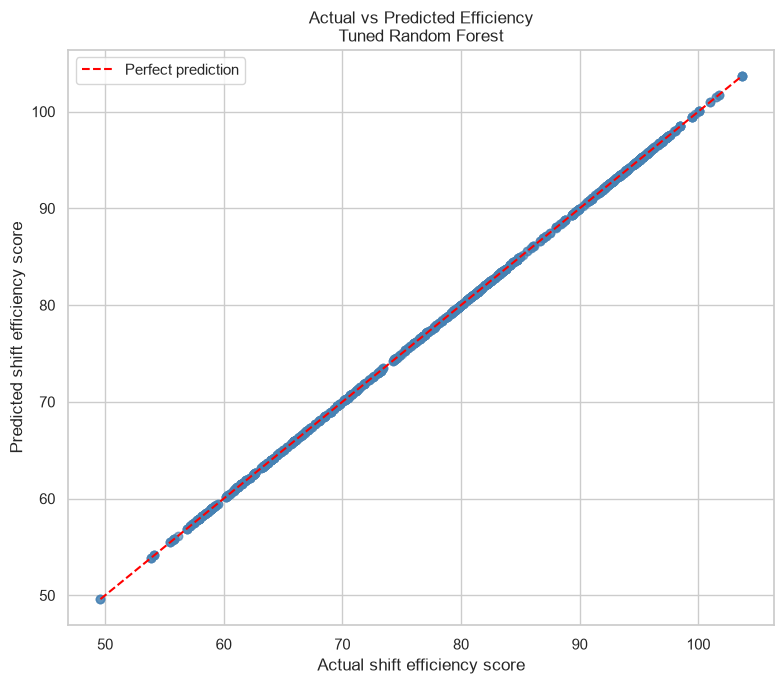

In [72]:
best_predictions = tuned_predictions

plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.40,
    color="steelblue"
)

minimum_value = min(
    y_test.min(),
    best_predictions.min()
)

maximum_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    color="red",
    label="Perfect prediction"
)

plt.title(
    "Actual vs Predicted Efficiency\n"
    "Tuned Random Forest"
)

plt.xlabel(
    "Actual shift efficiency score"
)

plt.ylabel(
    "Predicted shift efficiency score"
)

plt.legend()
plt.tight_layout()
plt.show()

In [73]:
residuals = (
    y_test.to_numpy()
    - best_predictions
)

residual_summary = pd.DataFrame({
    "Measure": [
        "Mean residual",
        "Minimum residual",
        "Maximum residual"
    ],
    "Result": [
        residuals.mean(),
        residuals.min(),
        residuals.max()
    ]
})

residual_summary

,Measure,Result
0,Mean residual,2.084937e-14
1,Minimum residual,-4.831691e-13
2,Maximum residual,5.115908e-13


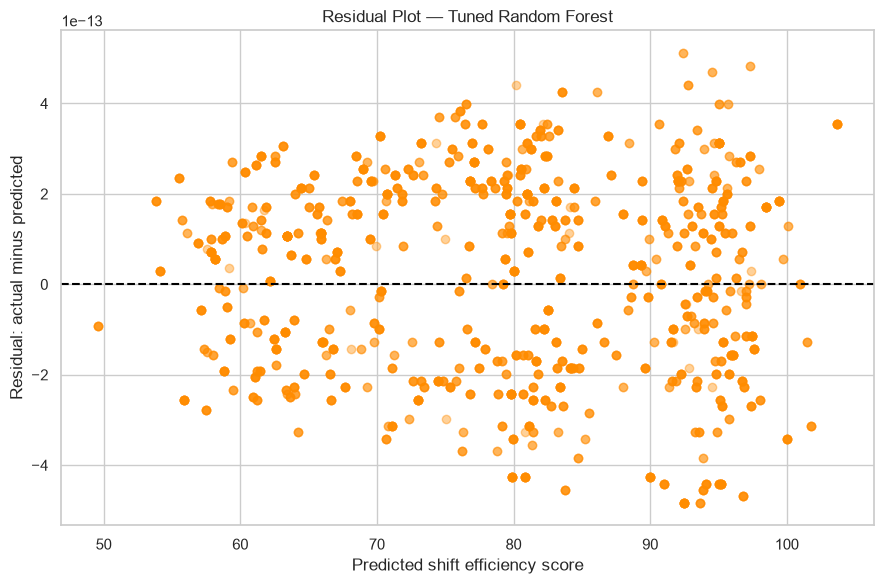

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.40,
    color="darkorange"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title(
    "Residual Plot — Tuned Random Forest"
)

plt.xlabel(
    "Predicted shift efficiency score"
)

plt.ylabel(
    "Residual: actual minus predicted"
)

plt.tight_layout()
plt.show()

In [75]:
best_model_summary = pd.DataFrame({
    "Measure": [
        "Numerical leading model",
        "Test MAE",
        "Test RMSE",
        "Test R-squared",
        "Best untuned model",
        "Best untuned RMSE",
        "Final status"
    ],
    "Result": [
        "Tuned Random Forest",
        round(tuned_mae, 4),
        round(tuned_rmse, 4),
        round(tuned_r2, 4),
        "LightGBM",
        0.2567,
        "Experimental candidate — leakage review required"
    ]
})

best_model_summary

,Measure,Result
0,Numerical leading model,Tuned Random Forest
1,Test MAE,0.0
2,Test RMSE,0.0
3,Test R-squared,1.0
4,Best untuned model,LightGBM
5,Best untuned RMSE,0.2567
6,Final status,Experimental candidate — leakage review required


In [76]:
model_directory = Path(
    "trained_models"
)

model_directory.mkdir(
    exist_ok=True
)

tuned_model_path = (
    model_directory
    / "tuned_random_forest.joblib"
)

joblib.dump(
    tuned_random_forest,
    tuned_model_path,
    compress=3
)

saved_models = pd.DataFrame({
    "Model": [
        "Tuned Random Forest"
    ],
    "File": [
        tuned_model_path.name
    ],
    "File exists": [
        tuned_model_path.exists()
    ]
})

saved_models

,Model,File,File exists
0,Tuned Random Forest,tuned_random_forest.joblib,True


In [77]:
reloaded_model = joblib.load(
    tuned_model_path
)

reloaded_predictions = (
    reloaded_model.predict(
        X_test.head(5)
    )
)

reload_test = pd.DataFrame({
    "Actual": (
        y_test.head(5).to_numpy()
    ),
    "Reloaded model prediction":
        reloaded_predictions
})

reload_test.round(2)

,Actual,Reloaded model prediction
0,99.44,99.44
1,74.85,74.85
2,95.57,95.57
3,77.78,77.78
4,71.81,71.81


In [78]:
unique_rows = (
    model_data
    .drop_duplicates()
    .shape[0]
)

duplicate_rows = (
    model_data
    .duplicated()
    .sum()
)

duplicate_percentage = (
    duplicate_rows
    / model_data.shape[0]
    * 100
)

training_complete = pd.concat(
    [X_train, y_train],
    axis=1
)

testing_complete = pd.concat(
    [X_test, y_test],
    axis=1
)

training_records = set(
    map(
        tuple,
        training_complete.to_numpy()
    )
)

test_rows_seen_in_training = sum(
    tuple(row) in training_records
    for row in testing_complete.to_numpy()
)

leakage_summary = pd.DataFrame({
    "Measure": [
        "Total rows",
        "Unique rows",
        "Duplicate rows",
        "Duplicate percentage",
        "Test rows also found in training",
        "Test-set overlap percentage"
    ],
    "Result": [
        model_data.shape[0],
        unique_rows,
        duplicate_rows,
        round(duplicate_percentage, 2),
        test_rows_seen_in_training,
        round(
            test_rows_seen_in_training
            / testing_complete.shape[0]
            * 100,
            2
        )
    ]
})

leakage_summary

,Measure,Result
0,Total rows,10117.00
1,Unique rows,483.00
2,Duplicate rows,9634.00
3,Duplicate percentage,95.23
4,Test rows also found in training,2024.00
5,Test-set overlap percentage,100.00


In [79]:
limitations_summary = pd.DataFrame({
    "Limitation": [
        "Restricted time coverage",
        "Exact duplicate records",
        "Train-test overlap",
        "Possible target leakage",
        "Limited hyperparameter tuning"
    ],
    "Evidence": [
        "Dataset covers only 1–3 January 2024",
        "9,634 of 10,117 rows are duplicates",
        "Every test row also appears in training",
        "Some predictors may be derived from efficiency calculations",
        "Only Random Forest received randomized tuning"
    ]
})

limitations_summary

,Limitation,Evidence
0,Restricted time coverage,Dataset covers only 1–3 January 2024
1,Exact duplicate records,"9,634 of 10,117 rows are duplicates"
2,Train-test overlap,Every test row also appears in training
3,Possible target leakage,Some predictors may be derived from efficiency...
4,Limited hyperparameter tuning,Only Random Forest received randomized tuning
